In [1]:
import sys
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

sys.path.append('..')
from config import DB_PATH

# 한글 폰트 설정
rcParams['font.family'] = 'AppleGothic'  # Mac
# rcParams['font.family'] = 'NanumGothic'  # Linux

# ================================================================
# STEP 0. 데이터 로드 (reviews JOIN neg/pos_reviews_classified)
# ================================================================

db_path = os.path.join('..', DB_PATH)
conn = sqlite3.connect(db_path)

# 부정 리뷰 + reviews 메타데이터 JOIN
neg_full = pd.read_sql_query("""
    SELECT n.*, r.refunded, r.review_date, r.timestamp_created
    FROM neg_reviews_classified n
    JOIN reviews r ON n.review_id = r.review_id
    WHERE n.classify_method = 'anthropic'
""", conn)

# 긍정 리뷰 + reviews 메타데이터 JOIN
pos_full = pd.read_sql_query("""
    SELECT p.*, r.refunded, r.review_date, r.timestamp_created
    FROM pos_reviews_classified p
    JOIN reviews r ON p.review_id = r.review_id
""", conn)


conn.close()

# datetime 변환
neg_full['review_date']  = pd.to_datetime(neg_full['review_date'])
neg_full['review_month'] = pd.to_datetime(neg_full['review_month'])
pos_full['review_date']  = pd.to_datetime(pos_full['review_date'])
pos_full['review_month'] = pd.to_datetime(pos_full['review_month'])

print(f'부정 리뷰 전체: {len(neg_full)}건')
print(f'긍정 리뷰 전체: {len(pos_full)}건')
print(f'\n부정 리뷰 환불 여부:\n{neg_full["refunded"].value_counts()}')

부정 리뷰 전체: 2032건
긍정 리뷰 전체: 4000건

부정 리뷰 환불 여부:
refunded
0    1963
1      69
Name: count, dtype: int64


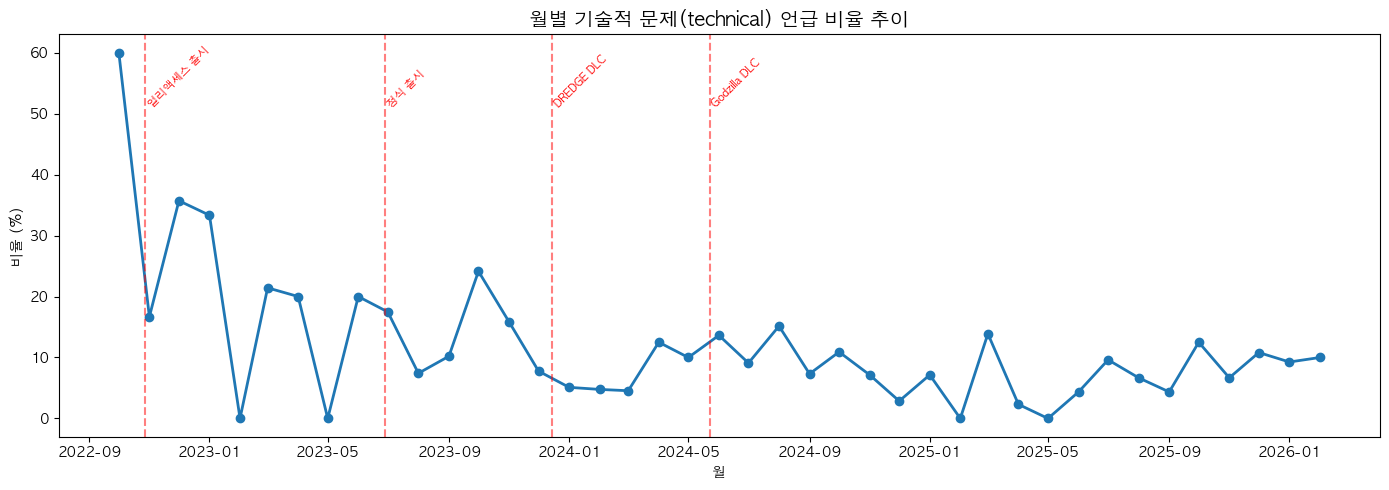


[STEP 1 완료] → 아래 표에서 변곡점 확인 후 STEP 2의 INFLECTION_DATE 수정
review_month  tech_ratio
  2022-10-01   60.000000
  2022-11-01   16.666667
  2022-12-01   35.714286
  2023-01-01   33.333333
  2023-02-01    0.000000
  2023-03-01   21.428571
  2023-04-01   20.000000
  2023-05-01    0.000000
  2023-06-01   20.000000
  2023-07-01   17.469880
  2023-08-01    7.407407
  2023-09-01   10.204082
  2023-10-01   24.137931
  2023-11-01   15.853659
  2023-12-01    7.758621
  2024-01-01    5.102041
  2024-02-01    4.761905
  2024-03-01    4.545455
  2024-04-01   12.500000
  2024-05-01   10.000000
  2024-06-01   13.636364
  2024-07-01    9.090909
  2024-08-01   15.151515
  2024-09-01    7.317073
  2024-10-01   10.909091
  2024-11-01    7.142857
  2024-12-01    2.857143
  2025-01-01    7.142857
  2025-02-01    0.000000
  2025-03-01   13.888889
  2025-04-01    2.307692
  2025-05-01    0.000000
  2025-06-01    4.347826
  2025-07-01    9.615385
  2025-08-01    6.666667
  2025-09-01    4.347826
  2025-10-01   12

In [2]:
# ================================================================
# STEP 1. 전체 부정 리뷰에서 기술적 문제 언급 월별 추이 → 변곡점 찾기
# ================================================================

tech_monthly = (
    neg_full.groupby('review_month')
    .apply(lambda x: (x['category'] == 'technical').sum() / len(x) * 100)
    .reset_index()
)
tech_monthly.columns = ['review_month', 'tech_ratio']

# 주요 이벤트 (config.py EVENTS 참고)
events = {
    '2022-10-28': '얼리액세스 출시',
    '2023-06-28': '정식 출시',
    '2023-12-15': 'DREDGE DLC',
    '2024-05-23': 'Godzilla DLC',
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tech_monthly['review_month'], tech_monthly['tech_ratio'], marker='o', linewidth=2)
ax.set_title('월별 기술적 문제(technical) 언급 비율 추이', fontsize=14)
ax.set_ylabel('비율 (%)')
ax.set_xlabel('월')

for date_str, label in events.items():
    ax.axvline(pd.to_datetime(date_str), color='red', linestyle='--', alpha=0.5)
    ax.text(pd.to_datetime(date_str), tech_monthly['tech_ratio'].max() * 0.85,
            label, fontsize=8, color='red', rotation=45)

plt.tight_layout()
plt.savefig('step1_tech_monthly_trend.png', dpi=150)
plt.show()
print('\n[STEP 1 완료] → 아래 표에서 변곡점 확인 후 STEP 2의 INFLECTION_DATE 수정')
print(tech_monthly.to_string(index=False))

In [3]:
# ================================================================
# STEP 3. 2시간 미만 환불 유저 분석
# ================================================================

casual_neg      = neg_full[neg_full['playtime_hours'] < 2].copy()
refunded_neg    = casual_neg[casual_neg['refunded'] == 1].copy()
nonrefunded_neg = casual_neg[casual_neg['refunded'] == 0].copy()

print(f'=== 2시간 미만 부정 유저 ({len(casual_neg)}건) ===')
print(f'  └ 환불: {len(refunded_neg)}건')
print(f'  └ 비환불: {len(nonrefunded_neg)}건')

# ── 3-1. 환불 유저: 얼리액세스 vs 비얼리액세스 ──
print(f'\n--- 환불 유저: 얼리액세스 여부 ---')
print(refunded_neg['written_during_early_access'].value_counts())

early_ref    = refunded_neg[refunded_neg['written_during_early_access'] == 1]
nonearly_ref = refunded_neg[refunded_neg['written_during_early_access'] == 0]

for group_name, df in [('얼리액세스', early_ref), ('비얼리액세스', nonearly_ref)]:
    print(f'\n{"="*60}')
    print(f'[{group_name}] {len(df)}건')
    if len(df) == 0:
        continue

    # 분류 라벨 분포
    print(f'\n  category:        {df["category"].value_counts().to_dict()}')
    print(f'  sub_category:    {df["sub_category"].value_counts().to_dict()}')
    print(f'  tone:            {df["tone"].value_counts().to_dict()}')
    print(f'  actual_sentiment:{df["actual_sentiment"].value_counts().to_dict()}')
    print(f'  confidence:      {df["confidence"].value_counts().to_dict()}')

=== 2시간 미만 부정 유저 (410건) ===
  └ 환불: 61건
  └ 비환불: 349건

--- 환불 유저: 얼리액세스 여부 ---
written_during_early_access
0    57
1     4
Name: count, dtype: int64

[얼리액세스] 4건

  category:        {'other': 2, 'technical': 1, 'repetition': 1}
  sub_category:    {'none': 3, 'company': 1}
  tone:            {'constructive': 3, 'emotional': 1}
  actual_sentiment:{'mixed_negative': 3, 'pure_negative': 1}
  confidence:      {'medium': 2, 'high': 2}

[비얼리액세스] 57건

  category:        {'gameplay': 24, 'other': 16, 'technical': 7, 'repetition': 7, 'company': 2, 'forced_neg': 1}
  sub_category:    {'none': 42, 'story_content': 6, 'repetition': 3, 'company': 3, 'technical': 2, 'gameplay': 1}
  tone:            {'constructive': 37, 'emotional': 14, 'mixed': 4, 'troll': 2}
  actual_sentiment:{'pure_negative': 34, 'mixed_negative': 21, 'joke': 2}
  confidence:      {'high': 38, 'medium': 14, 'low': 5}


In [4]:
# ── 3-2. 비얼리액세스 환불 유저: technical 제외 불만 분석 ──

# technical 제외
nonearly_ref_nontec = nonearly_ref[nonearly_ref['category'] != 'technical']

print(f'비얼리액세스 환불 유저: {len(nonearly_ref)}건 중 technical 제외 {len(nonearly_ref_nontec)}건')

print('\n카테고리:')
print(nonearly_ref_nontec['category'].value_counts().to_string())
print('\nsub_category (top5):')
print(nonearly_ref_nontec['sub_category'].value_counts().head(5).to_string())
print('\ntone:')
print(nonearly_ref_nontec['tone'].value_counts().to_string())
print('\nactual_sentiment:')
print(nonearly_ref_nontec['actual_sentiment'].value_counts().to_string())

# 전체 리뷰 출력
print(f'\n--- 전체 리뷰 ---')
for _, row in nonearly_ref_nontec.iterrows():
    print(f'[{row["playtime_hours"]:.1f}h] cat:{row["category"]} sub:{row["sub_category"]} tone:{row["tone"]} sentiment:{row["actual_sentiment"]}')
    print(f'  reason: {row["reason"]}')
    print(f'  {row["review_text"][:1000]}')
    print()

비얼리액세스 환불 유저: 57건 중 technical 제외 50건

카테고리:
category
gameplay      24
other         16
repetition     7
company        2
forced_neg     1

sub_category (top5):
sub_category
none             36
story_content     6
company           3
repetition        2
technical         2

tone:
tone
constructive    31
emotional       13
mixed            4
troll            2

actual_sentiment:
actual_sentiment
pure_negative     29
mixed_negative    19
joke               2

--- 전체 리뷰 ---
[0.2h] cat:gameplay sub:none tone:emotional sentiment:pure_negative
  reason: Dislikes the core restaurant management mechanics and finds clicking-based gameplay tedious, gave up after 15 minutes.
  I don't understand this genre of games where you literally have to work a tedious job. Like creating food for impatient customers by clicking around, which is fully based on old Flash games that were free to play. I was hoping for a 2D version of subnautica, but I gave up after 15 minutes going through menus and boring mecha

In [5]:
# 얼리액세스 환불 유저: technical 제외
early_ref_nontec = early_ref[early_ref['category'] != 'technical']

print(f'얼리액세스 환불 유저: {len(early_ref)}건 중 technical 제외 {len(early_ref_nontec)}건')

print('\n카테고리:')
print(early_ref_nontec['category'].value_counts().to_string())
print('\nsub_category:')
print(early_ref_nontec['sub_category'].value_counts().to_string())
print('\ntone:')
print(early_ref_nontec['tone'].value_counts().to_string())
print('\nactual_sentiment:')
print(early_ref_nontec['actual_sentiment'].value_counts().to_string())

print(f'\n--- 전체 리뷰 ---')
for _, row in early_ref_nontec.iterrows():
    print(f'[{row["playtime_hours"]:.1f}h] cat:{row["category"]} sub:{row["sub_category"]} tone:{row["tone"]} sentiment:{row["actual_sentiment"]}')
    print(f'  reason: {row["reason"]}')
    print(f'  {row["review_text"][:300]}')
    print()

얼리액세스 환불 유저: 4건 중 technical 제외 3건

카테고리:
category
other         2
repetition    1

sub_category:
sub_category
none       2
company    1

tone:
tone
constructive    2
emotional       1

actual_sentiment:
actual_sentiment
mixed_negative    2
pure_negative     1

--- 전체 리뷰 ---
[0.6h] cat:other sub:none tone:emotional sentiment:pure_negative
  reason: Personal taste complaint about restaurant portion being boring, wants diving-only gameplay.
  Mabe it would be a great diver game without this boring restaurant part.
De-installed after some minutes.
Dear devs, please let the gamers just dive and get off this boring restaurant.


[1.4h] cat:repetition sub:company tone:constructive sentiment:mixed_negative
  reason: Primary complaint about repetitive fishing-selling loop, secondary about pricing.
  내 기준에 압긍할 게임정도는 아님.
만원 이하면 딱 적당하다고 봅니다.
고기잡고 장사하고 그냥 그거 반복에 약간의 미니게임 들어가있는 수준인데
그 반복이 재미가 있다..? 글쎄 재미는 있지만 어릴때부터 게임해오던 사람한테는 하다보면 좀 현타옴
거의 모든게임에 새로움을 못느끼는 나같은 사람한테는 비추

[0.2h] cat:other sub:none ton

In [6]:
# ================================================================
# STEP 4. 2시간 미만 비환불 부정 유저
# ================================================================

nonrefunded_neg_nontec = nonrefunded_neg[nonrefunded_neg['category'] != 'technical'].copy()

print(f'=== 비환불 부정 유저 ({len(nonrefunded_neg)}건) → technical 제외 {len(nonrefunded_neg_nontec)}건 ===')

early_nonref    = nonrefunded_neg_nontec[nonrefunded_neg_nontec['written_during_early_access'] == 1]
nonearly_nonref = nonrefunded_neg_nontec[nonrefunded_neg_nontec['written_during_early_access'] == 0]

for group_name, df in [('얼리액세스', early_nonref), ('비얼리액세스', nonearly_nonref)]:
    print(f'\n{"="*60}')
    print(f'[{group_name}] {len(df)}건')
    if len(df) == 0:
        continue

    # 전체 태그 분포
    print(f'\n  category:         {df["category"].value_counts().to_dict()}')
    print(f'  sub_category:     {df["sub_category"].value_counts().to_dict()}')
    print(f'  tone:             {df["tone"].value_counts().to_dict()}')
    print(f'  actual_sentiment: {df["actual_sentiment"].value_counts().to_dict()}')
    print(f'  confidence:       {df["confidence"].value_counts().to_dict()}')

    # 카테고리별 샘플 5개
    print(f'\n  --- 카테고리별 샘플 ---')
    for cat in df['category'].value_counts().index:
        cat_df = df[df['category'] == cat]
        print(f'\n  [{cat}] {len(cat_df)}건')
        for _, row in cat_df.head(5).iterrows():
            text = row['review_text'][:2000]
            print(f'    [{row["playtime_hours"]:.1f}h] sub:{row["sub_category"]} tone:{row["tone"]} sentiment:{row["actual_sentiment"]} conf:{row["confidence"]}')
            print(f'    {text}')
            print()

=== 비환불 부정 유저 (349건) → technical 제외 274건 ===

[얼리액세스] 26건

  category:         {'gameplay': 13, 'other': 5, 'repetition': 4, 'company': 3, 'story_content': 1}
  sub_category:     {'none': 19, 'gameplay': 3, 'repetition': 2, 'company': 2}
  tone:             {'constructive': 12, 'emotional': 6, 'mixed': 6, 'troll': 2}
  actual_sentiment: {'pure_negative': 12, 'mixed_negative': 11, 'joke': 2, 'positive_but_negative_vote': 1}
  confidence:       {'high': 16, 'medium': 5, 'low': 3, '0.9': 2}

  --- 카테고리별 샘플 ---

  [gameplay] 13건
    [0.4h] sub:repetition tone:mixed sentiment:mixed_negative conf:medium
    뭘 좋아할지 몰라서 다 넣어봤어식

얼리면 다 용서되는게 아니다 하지만 잘만들긴했다.

녹차 맥주 와사비등 끝나면 바로 화면좀 닫게해주세요. 뭡니까? 띠링 하면서 2 ~ 5초 더잡아먹음(타이쿤겜안해봄?)

라모 운송퀘스트에서 죽으면 세이브 포인트 실화냐? 

어인터 빨리 이용할수있게 듀공있더만 라이딩좀 만들던가 택시좀 만들어요 ㅡㅡ

어인터가서부터 게임이 ㅈㄴ 노잼되버림 흔한 K게임의 숙제겜...

그리고 제작자님들아 생각해보셈 키보드는 왼손 , 마우스는 오른손임 ㅇㅋ?

마우스 갑자기 손때고 A , D 나 스페이스 연타하러 올까? ㅈㄴ 번거로운 게임임 마우스 클릭도 ㅈㄴ 때려야함

그래픽에 속지마라 아직 K게임이다. 추후업데이트 후 다시씀

-------------
마지막으로 전기가오리 발

In [7]:
# ================================================================
# STEP 5. 2시간 미만 긍정 유저 분석
# ================================================================

casual_pos      = pos_full[pos_full['playtime_hours'] < 2].copy()
refunded_pos    = casual_pos[casual_pos['refunded'] == 1].copy()
nonrefunded_pos = casual_pos[casual_pos['refunded'] == 0].copy()

print(f'=== 2시간 미만 긍정 유저 ({len(casual_pos)}건) ===')
print(f'  └ 환불: {len(refunded_pos)}건')
print(f'  └ 비환불: {len(nonrefunded_pos)}건')

for group_name, df in [('환불', refunded_pos), ('비환불', nonrefunded_pos)]:
    print(f'\n{"="*60}')
    print(f'[{group_name}] {len(df)}건')
    if len(df) == 0:
        continue

    # 전체 태그 분포
    print(f'\n  aspect:        {df["aspect"].value_counts().to_dict()}')
    print(f'  sub_aspect:    {df["sub_aspect"].value_counts().to_dict()}')
    print(f'  has_criticism: {df["has_criticism"].value_counts().to_dict()}')
    print(f'  criticism_topic: {df["criticism_topic"].value_counts().to_dict()}')
    print(f'  confidence:    {df["confidence"].value_counts().to_dict()}')

    # aspect별 샘플 5개
    print(f'\n  --- aspect별 샘플 ---')
    for aspect in df['aspect'].value_counts().index:
        asp_df = df[df['aspect'] == aspect]
        print(f'\n  [{aspect}] {len(asp_df)}건')
        for _, row in asp_df.head(5).iterrows():
            print(f'    [{row["playtime_hours"]:.1f}h] sub:{row["sub_aspect"]} has_criticism:{row["has_criticism"]} conf:{row["confidence"]}')
            if row["has_criticism"] == 'true' and row["criticism_topic"]:
                print(f'    criticism: {row["criticism_topic"]}')
            print(f'    reason: {row["reason"]}')
            print(f'    {row["review_text"][:2000]}')
            print()

=== 2시간 미만 긍정 유저 (641건) ===
  └ 환불: 7건
  └ 비환불: 634건

[환불] 7건

  aspect:        {'other_positive': 3, 'atmosphere': 2, 'gameplay_fun': 1, 'story_charm': 1}
  sub_aspect:    {'none': 5, 'variety': 1, 'gameplay_fun': 1}
  has_criticism: {'no': 4, 'yes': 3}
  criticism_topic: {'none': 4, 'gameplay': 2, 'other': 1}
  confidence:    {'high': 3, 'medium': 3, 'low': 1}

  --- aspect별 샘플 ---

  [other_positive] 3건
    [0.9h] sub:none has_criticism:yes conf:medium
    reason: 평가는 좋다고 하지만 우선순위가 낮아 나중에 하겠다는 비판적 태도
    평대로 좋다. 하지만 할 게임이 많은 나로선 구지?
나중에 다시 오기로...

    [1.9h] sub:none has_criticism:no conf:low
    reason: Minimal praise without specific aspects identified.
    decent

    [1.4h] sub:none has_criticism:no conf:medium
    reason: Generic positive statement without specific aspects.
    재밌


  [atmosphere] 2건
    [1.9h] sub:none has_criticism:yes conf:high
    reason: Praises beauty but criticizes slow pace and inability to get hooked in early game
    Game's beautiful, gameplay aight. 

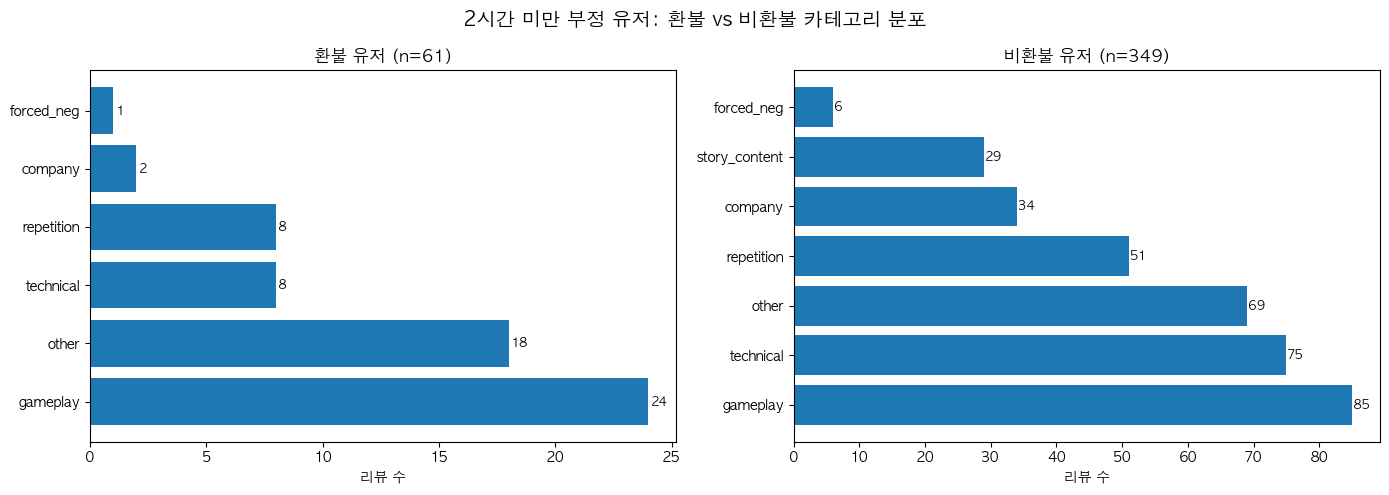

[STEP 6 완료]


In [8]:
# ================================================================
# STEP 6. 환불 vs 비환불 카테고리 비교 시각화
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('2시간 미만 부정 유저: 환불 vs 비환불 카테고리 분포', fontsize=14)

for ax, df, title in zip(
    axes,
    [refunded_neg, nonrefunded_neg],
    ['환불 유저', '비환불 유저']
):
    if len(df) > 0:
        cat_counts = df['category'].value_counts()
        ax.barh(cat_counts.index, cat_counts.values)
        ax.set_title(f'{title} (n={len(df)})')
        ax.set_xlabel('리뷰 수')
        for i, v in enumerate(cat_counts.values):
            ax.text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('step6_refund_vs_nonrefund_category.png', dpi=150)
plt.show()
print('[STEP 6 완료]')